# Decision Tree Classifier

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from matplotlib.legend_handler import HandlerLine2D
from sklearn.model_selection import train_test_split

df = pd.read_csv('https://raw.githubusercontent.com/marvv0905/ISOM3360-project/refs/heads/main/datasets/shopping_dataset_dummyCoded.csv')

### Variable set up
- Encode target variable, since cannot use binary to represent due to multi-classed values (Store / Hybrid / Online)
- Splitting features and target variable
- Splitting into training/ test set

In [3]:
#Encoding target variable
encoder = LabelEncoder()

targ = 'shopping_preference'
features = [col for col in df.columns if col != targ]

x = df[features]
y = encoder.fit_transform(df[targ])

#stratify used due to unbalanced dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state = 42)


print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


{'Hybrid': 0, 'Online': 1, 'Store': 2}
(8252, 28) (3537, 28) (8252,) (3537,)


## Base model

In [4]:
#fit model with train data
base_model = DecisionTreeClassifier()
base_model.fit(x_train, y_train)

dec_tree = base_model.tree_
print(dec_tree.node_count)

fig = plt.figure(figsize=(100,100))
_ = tree.plot_tree(base_model,
                   feature_names = features,
                   class_names= list(encoder.classes_),
                   filled=True)

635


In [5]:
pred_test = base_model.predict(x_test)
print(f'accuracy = {accuracy_score(y_test, pred_test, normalize=True, sample_weight=None)}')
print(classification_report(y_test, pred_test, target_names=encoder.classes_))
print('confusion matrix', '\n', confusion_matrix(y_test, pred_test))

pred_train = base_model.predict(x_train)
print(f'Training data accuracy = {accuracy_score(y_train, pred_train, normalize=True, sample_weight=None)}')


accuracy = 0.9287531806615776
              precision    recall  f1-score   support

      Hybrid       0.20      0.22      0.21       111
      Online       0.77      0.81      0.79       353
       Store       0.98      0.97      0.97      3073

    accuracy                           0.93      3537
   macro avg       0.65      0.67      0.66      3537
weighted avg       0.93      0.93      0.93      3537

confusion matrix 
 [[  24   40   47]
 [  42  287   24]
 [  53   46 2974]]
Training data accuracy = 1.0


Out of 111 Hybrid test samples, only 23 were correctly identified. 49 were misclassified as Store and 39 as Online. There is a problem stemming from class imbalance.

Moreover, the model has memorised the training data and generalised poorly due to overfitting. A limit should be set on tree depth.

## Tuning the base model

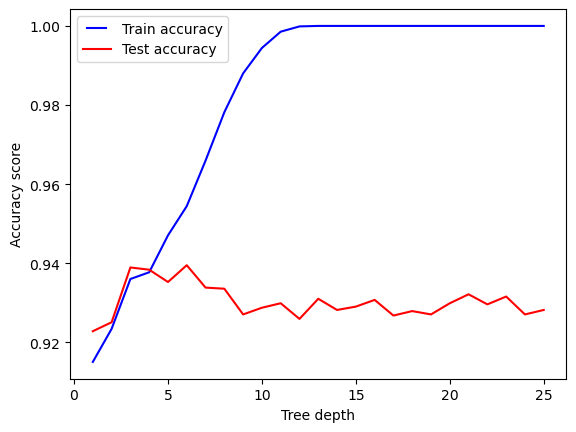

In [17]:
max_depth = np.linspace(1, 25, 25, dtype=int)

train_resultT = []
test_resultT = []

for m in max_depth:
    dtree = DecisionTreeClassifier(max_depth=m)
    dtree.fit(x_train, y_train)

    train_pred = dtree.predict(x_train)
    accuracy = accuracy_score(y_train, train_pred, normalize=True, sample_weight=None)
    train_resultT.append(accuracy)

    test_pred = dtree.predict(x_test)
    accuracy1 = accuracy_score(y_test, test_pred, normalize=True, sample_weight=None)
    test_resultT.append(accuracy1)

line1, = plt.plot(max_depth, train_resultT, 'b', label='Train accuracy')
line2, = plt.plot(max_depth, test_resultT, 'r', label='Test accuracy')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('Accuracy score')
plt.xlabel('Tree depth')
plt.show()

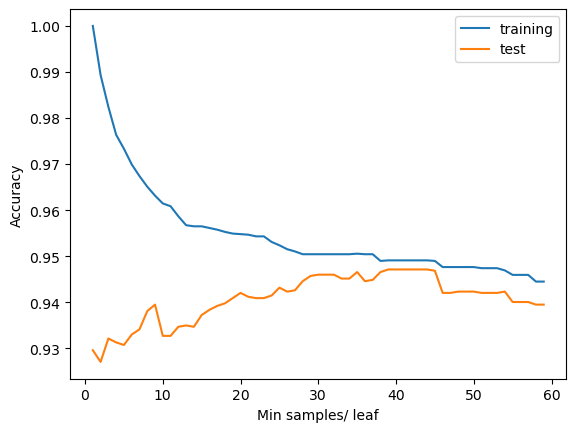

In [19]:
min_leaves = range(1,60)

train_resultL = []
test_resultL = []

for n in min_leaves:
    dtreeL = DecisionTreeClassifier(min_samples_leaf=n, random_state=4)
    dtreeL.fit(x_train, y_train)

    train_predL = dtreeL.predict(x_train)
    accuracyL = accuracy_score(y_train, train_predL, normalize=True, sample_weight=None)
    train_resultL.append(accuracyL)

    test_predL = dtreeL.predict(x_test)
    accuracyL1 = accuracy_score(y_test, test_predL, normalize=True, sample_weight=None)
    test_resultL.append(accuracyL1)

results = pd.DataFrame({"min_leaves": min_leaves, "training": train_resultL, "test":test_resultL})
results.plot("min_leaves")
plt.ylabel("Accuracy")
plt.xlabel("Min samples/ leaf")
plt.show()

### Using gridsearchCV for best parameters

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': range(1, 50, 1),'min_samples_leaf': range(1, 60, 5)}
dtree3 = DecisionTreeClassifier(random_state=42, class_weight = 'balanced')

grid_search = GridSearchCV(estimator = dtree3, param_grid = param_grid, cv = 5,scoring = 'f1_macro')
grid_search.fit(x_train, y_train)

print("Best Hyperparameters found", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)


Best Hyperparameters found {'max_depth': 13, 'min_samples_leaf': 1}
Best Cross-Validation Accuracy: 0.6534981578113768


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


        it seems that an optimal hyperparameter would be max depth = 13, and min samples/ leaf = 1

### Applying it to the model:

In [84]:
final_model = DecisionTreeClassifier(criterion="entropy", max_depth=13, min_samples_leaf=1, class_weight='balanced')
final_model.fit(x_train, y_train)

pred_test3 = final_model.predict(x_test)
print(f'accuracy = {accuracy_score(y_test, pred_test3, normalize=True, sample_weight=None)}')
print('classification report:', '\n',classification_report(y_test,pred_test3,target_names=encoder.classes_))
print('confusion matrix', '\n', confusion_matrix(y_test, pred_test3))

pred_train3 = final_model.predict(x_train)
print(f'Training data accuracy = {accuracy_score(y_train, pred_train3, normalize=True, sample_weight=None)}')

accuracy = 0.9281877297144473
classification report: 
               precision    recall  f1-score   support

      Hybrid       0.24      0.32      0.28       111
      Online       0.81      0.78      0.79       353
       Store       0.97      0.97      0.97      3073

    accuracy                           0.93      3537
   macro avg       0.68      0.69      0.68      3537
weighted avg       0.94      0.93      0.93      3537

confusion matrix 
 [[  36   37   38]
 [  38  276   39]
 [  73   29 2971]]
Training data accuracy = 0.98691226369365
